# Face Recognition with Python

This notebook demonstrates how to perform face recognition using Python libraries. We will:
- Install and import required libraries
- Load and display sample images
- Detect faces in images
- Encode faces for recognition
- Compare and recognize faces
- Visualize recognition results

## 1. Install and Import Required Libraries
We will install the necessary libraries and import them for use in this notebook.

In [2]:
pip install face_recognition

  Using cached face_recognition-1.3.0-py2.py3-none-any.whl.metadata (21 kB)
  Using cached face_recognition_models-0.3.0.tar.gz (100.1 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached dlib-20.0.0.tar.gz (3.3 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Using cached face_recognition-1.3.0-py2.py3-none-any.whl (15 kB)
Using cached click-8.3.1-py3-no

In [1]:
# Install required libraries (uncomment if running for the first time)
# !pip install face_recognition numpy matplotlib

import face_recognition
import numpy as np
import matplotlib.pyplot as plt

c:\Users\devid\Desktop\Nexperts Academy\AIML-nexperts2\.venv\Lib\site-packages\face_recognition_models\__init__.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


## 2. Load and Display Sample Images
We will load sample images containing faces and display them using matplotlib.

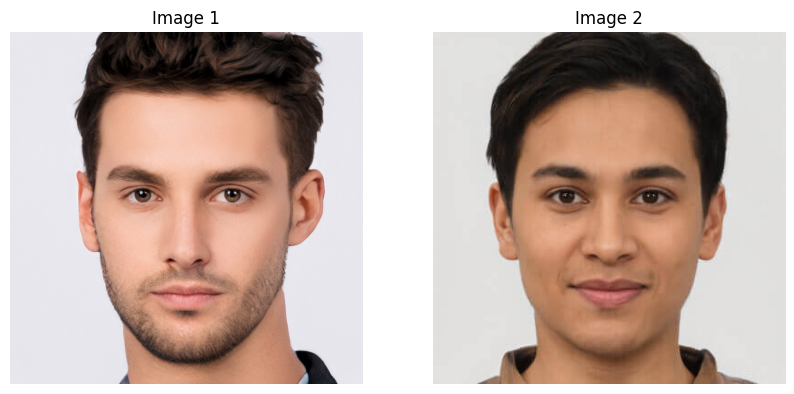

In [3]:
# Load sample images (replace with your own image paths if needed)
image_1 = face_recognition.load_image_file('image1.png')
image_2 = face_recognition.load_image_file('image2.png')

# Display the images
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(image_1)
ax[0].set_title('Image 1')
ax[0].axis('off')
ax[1].imshow(image_2)
ax[1].set_title('Image 2')
ax[1].axis('off')
plt.show()

## 3. Detect Faces in Images
We will use face_recognition to locate faces in the loaded images and visualize the detected face locations.

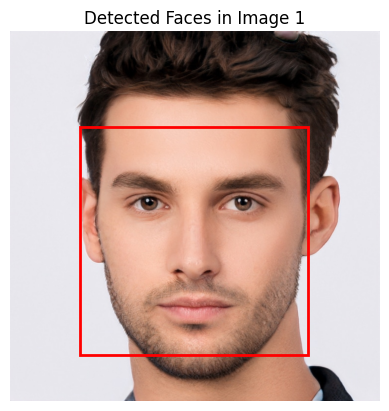

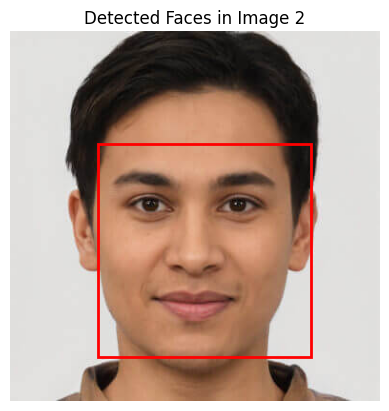

In [4]:
# Detect faces in both images
face_locations_1 = face_recognition.face_locations(image_1)
face_locations_2 = face_recognition.face_locations(image_2)

# Visualize detected faces on images
def show_faces(image, face_locations, title):
    plt.imshow(image)
    ax = plt.gca()
    for (top, right, bottom, left) in face_locations:
        rect = plt.Rectangle((left, top), right - left, bottom - top, fill=False, color='red', linewidth=2)
        ax.add_patch(rect)
    plt.title(title)
    plt.axis('off')
    plt.show()

show_faces(image_1, face_locations_1, 'Detected Faces in Image 1')
show_faces(image_2, face_locations_2, 'Detected Faces in Image 2')

## 4. Encode Faces for Recognition
We will extract face encodings from the detected faces to create numerical representations for recognition.

In [5]:
# Extract face encodings for each detected face
encodings_1 = face_recognition.face_encodings(image_1, face_locations_1)
encodings_2 = face_recognition.face_encodings(image_2, face_locations_2)

print(f"Number of faces encoded in Image 1: {len(encodings_1)}")
print(f"Number of faces encoded in Image 2: {len(encodings_2)}")

Number of faces encoded in Image 1: 1
Number of faces encoded in Image 2: 1


## 5. Compare and Recognize Faces
We will compare face encodings between images to determine if faces match, and print the recognition results.

In [11]:
# Compare faces between images
results = []
for i, encoding_2 in enumerate(encodings_2):
    matches = face_recognition.compare_faces(encodings_1, encoding_2)
    results.append(matches)
    print(f"Face {i+1} in Image 2 matches faces in Image 1: {matches}")

Face 1 in Image 2 matches faces in Image 1: [np.False_]


## 6. Visualize Recognition Results
We will draw bounding boxes and labels on the images to show recognized faces using matplotlib.

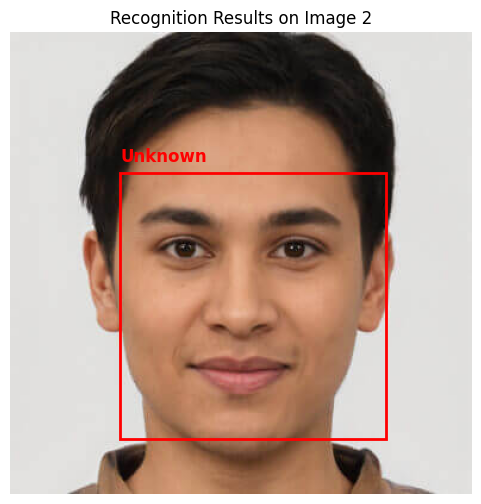

In [9]:
# Visualize recognition results on Image 2
image_2_copy = image_2.copy()
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(image_2_copy)
for i, (top, right, bottom, left) in enumerate(face_locations_2):
    color = 'green' if any(results[i]) else 'red'
    rect = plt.Rectangle((left, top), right - left, bottom - top, fill=False, color=color, linewidth=2)
    ax.add_patch(rect)
    label = 'Match' if any(results[i]) else 'Unknown'
    ax.text(left, top - 10, label, color=color, fontsize=12, weight='bold')
plt.title('Recognition Results on Image 2')
plt.axis('off')
plt.show()